# K08_03 - SVM HOG Pipeline

## Lernziele
- HOG-Merkmale als robuste Bildrepraesentation verstehen
- den Mehrwert von Feature Engineering gegenueber Rohpixeln empirisch erleben
- eine SVM-Pipeline auf echten Bilddaten einsetzen
- die Rolle von Feature Engineering fuer klassische Bildklassifikation reflektieren

## Datensatz: Labeled Faces in the Wild (LFW)

Dieses Notebook arbeitet mit dem `fetch_lfw_people`-Datensatz.
Er enthaelt **echte Pressefotos** bekannter Persoenlichkeiten mit realen Bedingungen:
unterschiedliche Beleuchtung, Hintergruende, Kamerawinkel und Bildqualitaet.

Genau hier entfaltet HOG seinen Vorteil:

```
Rohpixel:  speichern absolute Helligkeit
           -> empfindlich gegenueber Beleuchtung und Kontrast

HOG:       beschreibt Kantenrichtungen
           -> robust gegenueber Beleuchtung, Kontrast und kleinen Verschiebungen
```

Bei sauber normierten Laborbildern (z. B. Olivetti Faces) ist dieser Unterschied
nicht sichtbar - bei echten Fotos schon.


## 1. Bibliotheken importieren


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import hog
from skimage.transform import resize

print('Alle Bibliotheken erfolgreich geladen')


Alle Bibliotheken erfolgreich geladen


## 2. Daten laden

`min_faces_per_person=70` behaelt nur Personen mit mindestens 70 Fotos.
Das ergibt einen gut balancierten Datensatz fuer die Klassifikation.
`resize=(0.4, 0.4)` skaliert die Bilder auf eine handliche Groesse.


In [2]:
# Hinweis: der erste Download dauert etwas laenger (~200 MB)
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

images = lfw.images          # Shape: (n, h, w)
y      = lfw.target
names  = lfw.target_names    # Klarnamen der Personen

n, h, w = images.shape
print(f'Anzahl Bilder:    {n}')
print(f'Bildgroesse:      {h} x {w} Pixel')
print(f'Anzahl Klassen:   {len(names)}')
print()
for i, name in enumerate(names):
    count = np.sum(y == i)
    print(f'  Klasse {i}: {name} ({count} Bilder)')


Anzahl Bilder:    1288
Bildgroesse:      50 x 37 Pixel
Anzahl Klassen:   7

  Klasse 0: Ariel Sharon (77 Bilder)
  Klasse 1: Colin Powell (236 Bilder)
  Klasse 2: Donald Rumsfeld (121 Bilder)
  Klasse 3: George W Bush (530 Bilder)
  Klasse 4: Gerhard Schroeder (109 Bilder)
  Klasse 5: Hugo Chavez (71 Bilder)
  Klasse 6: Tony Blair (144 Bilder)


### Beispielbilder anzeigen


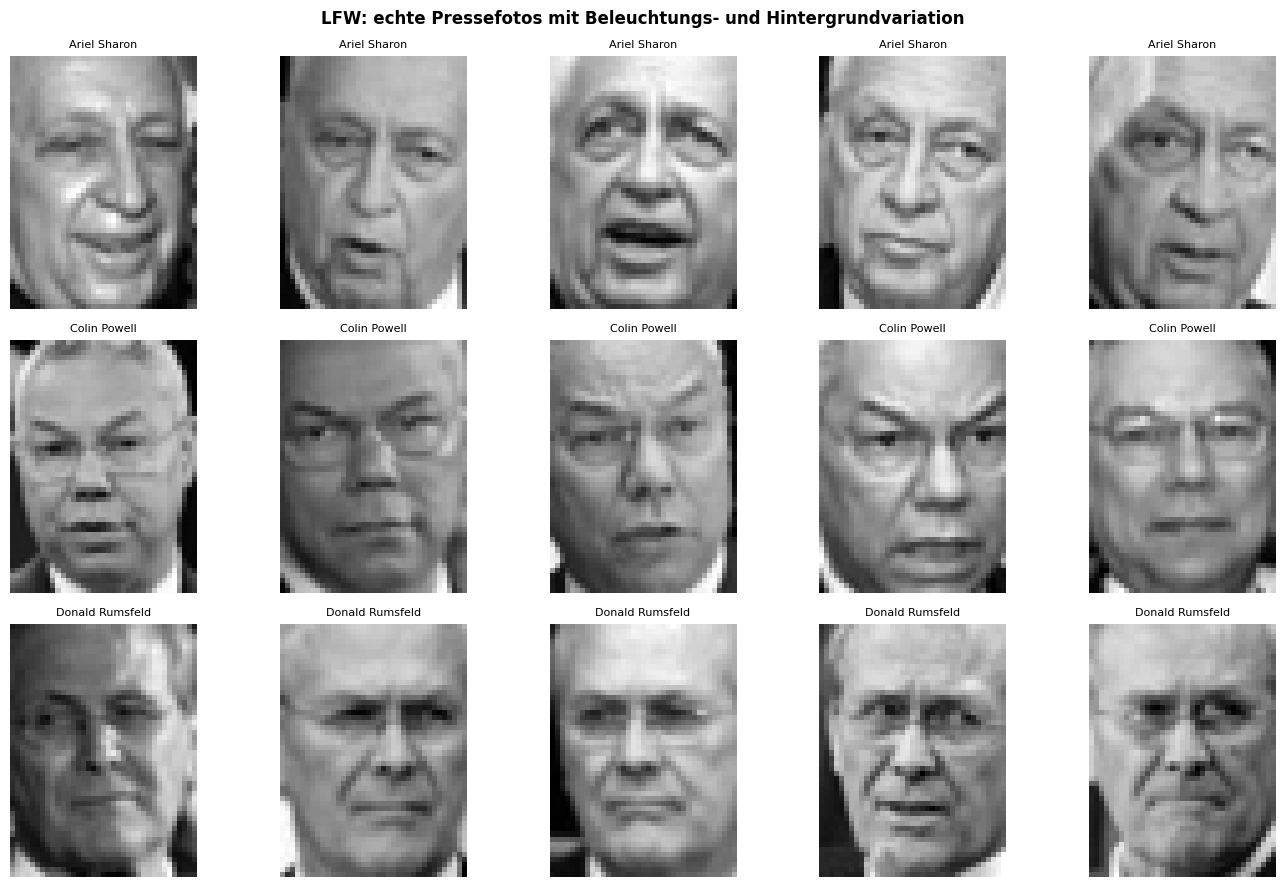

Beobachtung: Beleuchtung, Hintergrund und Kamerawinkel variieren stark.
Genau hier hat HOG gegenueber Rohpixeln einen Vorteil.


In [3]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for cls_idx in range(min(len(names), 3)):
    idxs = np.where(y == cls_idx)[0][:5]
    for col, idx in enumerate(idxs):
        axes[cls_idx, col].imshow(images[idx], cmap='gray')
        axes[cls_idx, col].set_title(names[cls_idx], fontsize=8)
        axes[cls_idx, col].axis('off')

plt.suptitle(
    'LFW: echte Pressefotos mit Beleuchtungs- und Hintergrundvariation',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Beobachtung: Beleuchtung, Hintergrund und Kamerawinkel variieren stark.')
print('Genau hier hat HOG gegenueber Rohpixeln einen Vorteil.')


## 3. HOG-Merkmale berechnen

HOG teilt das Bild in Zellen auf und beschreibt pro Zelle die
vorherrschenden Kantenrichtungen als Histogramm.
Das Ergebnis ist unabhaengig von der absoluten Helligkeit eines Bildes -
eine '7'-Linie bleibt eine '7'-Linie, egal ob das Bild hell oder dunkel ist.


In [4]:
def compute_hog(imgs, pixels_per_cell=(8,8), cells_per_block=(2,2)):
    return np.array([
        hog(img,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            feature_vector=True)
        for img in imgs
    ])

X_hog = compute_hog(images)
X_raw = images.reshape(n, -1)

print(f'Rohpixel-Features pro Bild: {X_raw.shape[1]}')
print(f'HOG-Features pro Bild:      {X_hog.shape[1]}')


Rohpixel-Features pro Bild: 1850
HOG-Features pro Bild:      540


### HOG visualisieren


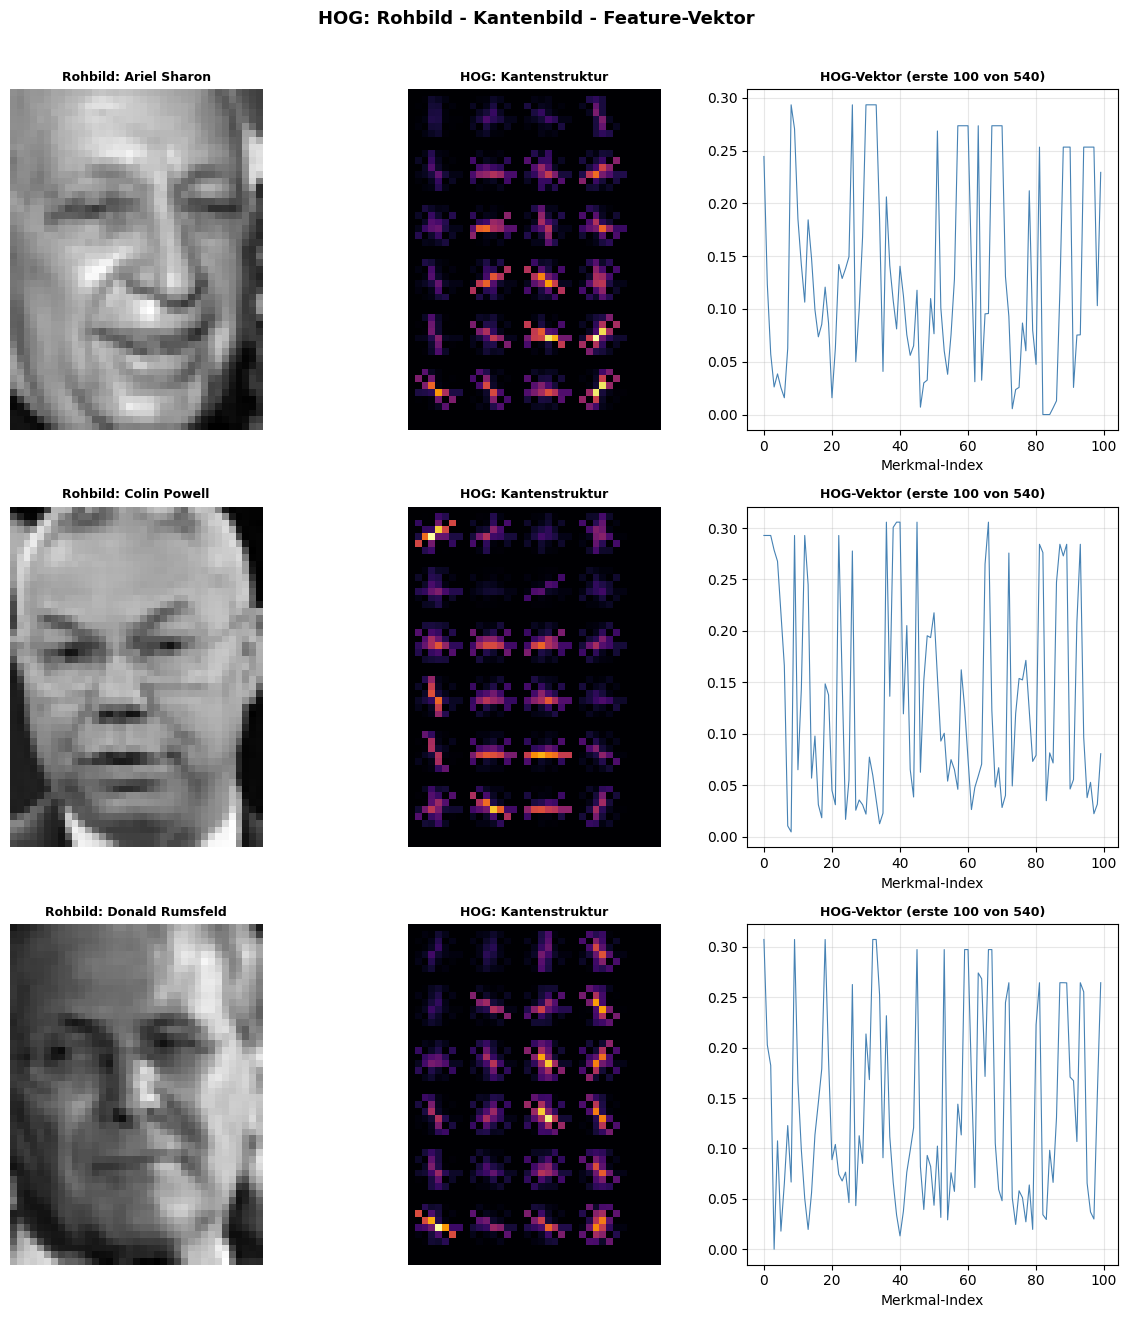

Beobachtung: HOG hebt Gesichtsstrukturen (Augenbrauen, Nasenruecken,
Kinnlinie) als Kantenmuster hervor - unabhaengig von der Beleuchtung.


In [5]:
# Drei verschiedene Personen zeigen
fig, axes = plt.subplots(3, 3, figsize=(12, 13))

for row, cls_idx in enumerate(range(min(3, len(names)))):
    idx = np.where(y == cls_idx)[0][0]
    img = images[idx]

    hog_feat, hog_img = hog(
        img, pixels_per_cell=(8,8), cells_per_block=(2,2),
        feature_vector=True, visualize=True
    )

    axes[row,0].imshow(img, cmap='gray')
    axes[row,0].set_title(f'Rohbild: {names[cls_idx]}', fontweight='bold', fontsize=9)
    axes[row,0].axis('off')

    axes[row,1].imshow(hog_img, cmap='inferno')
    axes[row,1].set_title('HOG: Kantenstruktur', fontweight='bold', fontsize=9)
    axes[row,1].axis('off')

    axes[row,2].plot(hog_feat[:100], color='steelblue', linewidth=0.8)
    axes[row,2].set_title(f'HOG-Vektor (erste 100 von {len(hog_feat)})', fontsize=9, fontweight='bold')
    axes[row,2].set_xlabel('Merkmal-Index')
    axes[row,2].grid(True, alpha=0.3)

plt.suptitle('HOG: Rohbild - Kantenbild - Feature-Vektor',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Beobachtung: HOG hebt Gesichtsstrukturen (Augenbrauen, Nasenruecken,')
print('Kinnlinie) als Kantenmuster hervor - unabhaengig von der Beleuchtung.')


## 4. Train/Test-Split


In [6]:
X_train_hog, X_test_hog, y_train, y_test = train_test_split(
    X_hog, y, test_size=0.25, random_state=42, stratify=y
)
X_train_raw, X_test_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Trainingsdaten: {X_train_hog.shape[0]} Bilder')
print(f'Testdaten:      {X_test_hog.shape[0]} Bilder')


Trainingsdaten: 966 Bilder
Testdaten:      322 Bilder


## 5. Vergleich: Rohpixel vs. HOG

Zwei identische SVM-Pipelines - einmal auf Rohpixeln, einmal auf HOG.
Der einzige Unterschied: die Eingabe-Features.


=== Vergleich: Rohpixel vs. HOG-Merkmale ===
Accuracy mit Rohpixeln:  0.8106
Accuracy mit HOG:        0.8820
Unterschied:             +0.0714


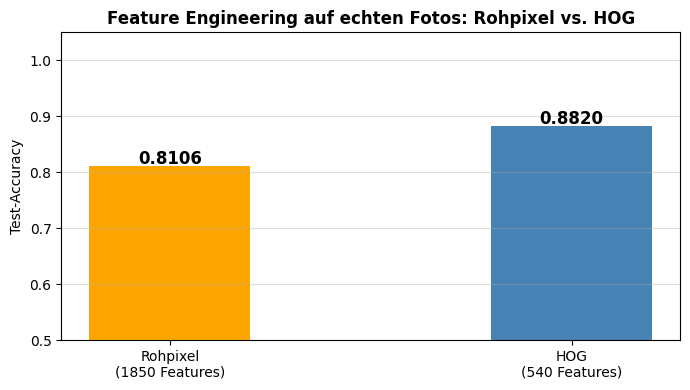

In [7]:
pipe_raw = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=5.0, gamma='scale'))
])
pipe_raw.fit(X_train_raw, y_train)
acc_raw = accuracy_score(y_test, pipe_raw.predict(X_test_raw))

pipe_hog = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=5.0, gamma='scale'))
])
pipe_hog.fit(X_train_hog, y_train)
acc_hog  = accuracy_score(y_test, pipe_hog.predict(X_test_hog))

print('=== Vergleich: Rohpixel vs. HOG-Merkmale ===')
print(f'Accuracy mit Rohpixeln:  {acc_raw:.4f}')
print(f'Accuracy mit HOG:        {acc_hog:.4f}')
diff = acc_hog - acc_raw
sign = '+' if diff >= 0 else ''
print(f'Unterschied:             {sign}{diff:.4f}')

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(
    [f'Rohpixel\n({X_raw.shape[1]} Features)', f'HOG\n({X_hog.shape[1]} Features)'],
    [acc_raw, acc_hog],
    color=['orange', 'steelblue'], width=0.4
)
for bar, acc in zip(bars, [acc_raw, acc_hog]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Test-Accuracy')
ax.set_title('Feature Engineering auf echten Fotos: Rohpixel vs. HOG',
             fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## 6. Konfusionsmatrix (HOG-Modell)


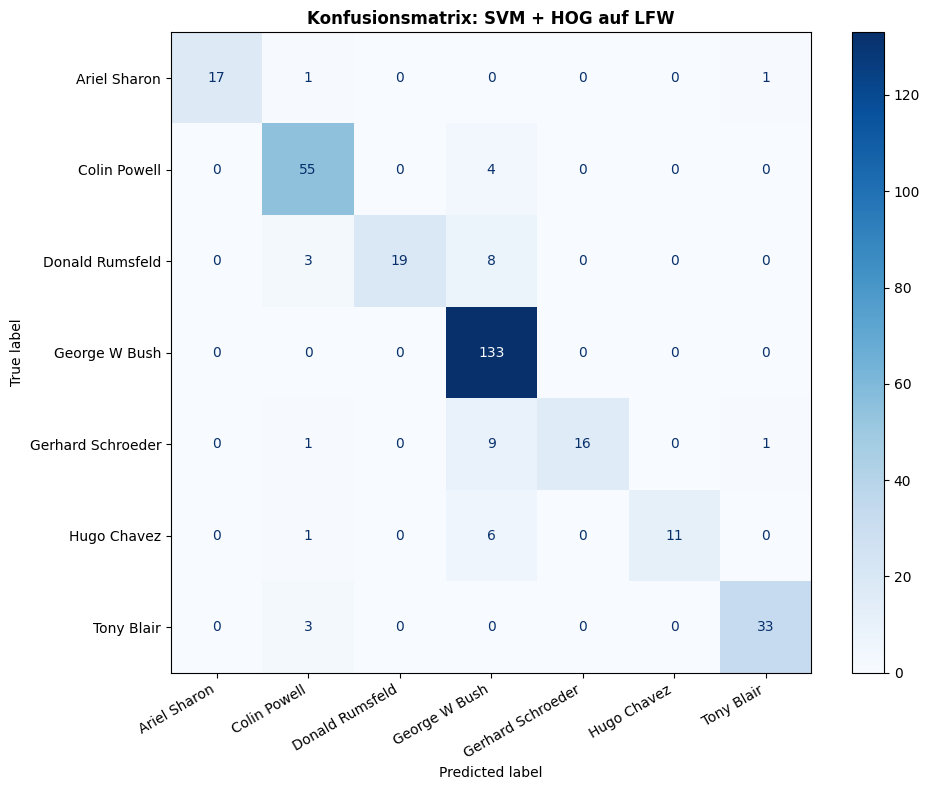

In [8]:
y_pred = pipe_hog.predict(X_test_hog)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=names).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Konfusionsmatrix: SVM + HOG auf LFW', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 8. Fazit

- HOG braucht **echte Bilddaten mit Variation** - bei normierten Labordaten verschwindet der Vorteil.
- Auf LFW mit realen Beleuchtungs- und Hintergrundunterschieden ist HOG robuster als Rohpixel.
- SVMs funktionieren gut auf aussagekraeftigen Merkmalen -
  **gute Features koennen ein einfaches Modell sehr leistungsfaehig machen.**
- Neuronale Netze (CNNs) ersetzen das manuelle Feature Engineering:
  sie lernen die besten Merkmale automatisch - aber nur bei grossen Datensaetzen.
